# Day 7 of ML 30-Days Challenge

# Task

Data Preprocessing & Missing Values: Learn about handling missing data points in a dataset. Explore different imputation strategies like mean, median, and mode, and understand when each is appropriate based on the data's distribution.

## Identifying Missing Data

You can identify missing data points in a DataFrame using `.isnull()` or `.isna()`, which return a boolean DataFrame. To get a count of missing values per column, use `.isnull().sum()`. You can also visualize missing data patterns using `seaborn.heatmap(df.isnull())`.

In [48]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Example DataFrame with missing data
data = {'A': [1, 2, np.nan, 4, 5],
        'B': [6, np.nan, 8, 9, 10],
        'C': [11, 12, 13, np.nan, 15],
        'D': [16, 17, 18, 19, np.nan]}
df = pd.DataFrame(data,index=['a', 'b', 'c', 'd', 'e'])

In [49]:
# Identify missing data
print("Boolean DataFrame for missing values:")
display(df.isnull())

Boolean DataFrame for missing values:


,A,B,C,D
a,False,False,False,False
b,False,True,False,False
c,True,False,False,False
d,False,False,True,False
e,False,False,False,True


In [50]:
# Count missing values per column
print("\nMissing values count per column:")
display(df.isnull().sum())


Missing values count per column:


,0
A,1
B,1
C,1
D,1


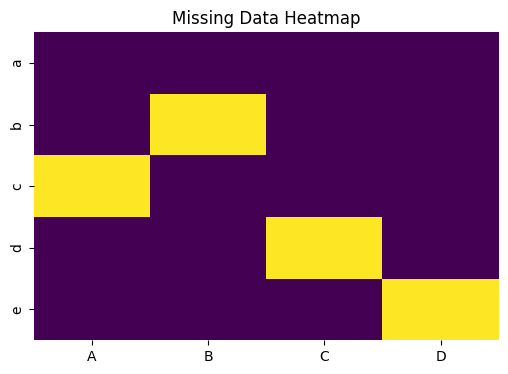

In [51]:
# Visualize missing data
plt.figure(figsize=(6, 4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis') # <- here yellow for missing and yeah! its not upside down
plt.title('Missing Data Heatmap')
plt.show()

## Dropping Missing Data (Pandas)

You can drop rows or columns with missing data using the `.dropna()` method.
- `df.dropna(axis=0)`: Drops rows containing any missing values.
- `df.dropna(axis=1)`: Drops columns containing any missing values.
- Use the `thresh` parameter to keep rows/columns with a certain number of non-NA values.

In [52]:
# Drop rows with any missing values
df_row_dropped = df.dropna(axis=0) # well yeah only one remains
print("DataFrame after dropping rows with missing values:")
display(df_row_dropped)

DataFrame after dropping rows with missing values:


,A,B,C,D
a,1.0,6.0,11.0,16.0


In [53]:
# Drop columns with any missing values
df_col_dropped = df.dropna(axis=1) # most of time row filter does the thing, don't require column in this
print("\nDataFrame after dropping columns with missing values:") # use only one at a time row/column filter
display(df_col_dropped)


DataFrame after dropping columns with missing values:


""
a
b
c
d
e


In [54]:
# Drop rows with less than 4 non-NaN values
df_thresh_row_dropped = df.dropna(axis=0, thresh=4) # this is row range filter works same as row filter but has range
print("\nDataFrame after dropping rows with less than 4 non-NaN values:")
display(df_thresh_row_dropped)


DataFrame after dropping rows with less than 4 non-NaN values:


,A,B,C,D
a,1.0,6.0,11.0,16.0


In [55]:
# Drop columns with less than 5 non-NaN values
df_thresh_col_dropped = df.dropna(axis=1, thresh=5) # this is column range filter works same as column filter but has range
print("\nDataFrame after dropping columns with less than 5 non-NaN values:")
display(df_thresh_col_dropped)


DataFrame after dropping columns with less than 5 non-NaN values:


""
a
b
c
d
e


## Imputing Missing Data (Pandas)

You can fill missing data with various strategies using the `.fillna()` method.
- Fill with a constant value: `df.fillna(0)`
- Fill with the mean of a column: `df['column'].fillna(df['column'].mean())`
- Fill with the median of a column: `df['column'].fillna(df['column'].median())`
- Fill with the mode for categorical data: `df['column'].fillna(df['column'].mode()[0])`

In [56]:
# Fill with a constant value (e.g., 0)
df_filled_constant = df.fillna(0) # if not for int type, i have putted missing word like -> df.fillna("missing")
print("DataFrame after filling NaN with 0:")
display(df_filled_constant)

DataFrame after filling NaN with 0:


,A,B,C,D
a,1.0,6.0,11.0,16.0
b,2.0,0.0,12.0,17.0
c,0.0,8.0,13.0,18.0
d,4.0,9.0,0.0,19.0
e,5.0,10.0,15.0,0.0


In [57]:
# Fill with the mean of a column (e.g., 'D')
df_filled_mean = df['D'].fillna(df['D'].mean())
df_filled_mean = df.copy()
df_filled_mean['D'] = df['D'].fillna(df['D'].mean())
print("\nDataFrame after filling NaN in column 'D' with the mean:")
display(df_filled_mean)


DataFrame after filling NaN in column 'D' with the mean:


,A,B,C,D
a,1.0,6.0,11.0,16.0
b,2.0,NaN,12.0,17.0
c,NaN,8.0,13.0,18.0
d,4.0,9.0,NaN,19.0
e,5.0,10.0,15.0,17.5


In [58]:
# Fill with the median of a column (e.g., 'D')
df_filled_median = df.copy()
df_filled_median['D'] = df['D'].fillna(df['D'].median())
print("\nDataFrame after filling NaN in column 'D' with the median:")
display(df_filled_median)


DataFrame after filling NaN in column 'D' with the median:


,A,B,C,D
a,1.0,6.0,11.0,16.0
b,2.0,NaN,12.0,17.0
c,NaN,8.0,13.0,18.0
d,4.0,9.0,NaN,19.0
e,5.0,10.0,15.0,17.5


In [59]:
# Fill with the mode of a column (e.g., 'D')
df_filled_mode = df.copy()
df_filled_mode['D'] = df['D'].fillna(df['D'].mode()[0])
print("\nDataFrame after filling NaN in column 'D' with the mode:")
display(df_filled_mode)


DataFrame after filling NaN in column 'D' with the mode:


,A,B,C,D
a,1.0,6.0,11.0,16.0
b,2.0,NaN,12.0,17.0
c,NaN,8.0,13.0,18.0
d,4.0,9.0,NaN,19.0
e,5.0,10.0,15.0,16.0


## Imputing Missing Data (Scikit-learn)

Scikit-learn provides the `SimpleImputer` class for imputing missing values with different strategies. You can also integrate it into a Pipeline.

In [60]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Create an instance of SimpleImputer with mean strategy
imputer_mean = SimpleImputer(strategy='mean')

# Use fit_transform on the DataFrame
df_imputed_mean = imputer_mean.fit_transform(df)
df_imputed_mean = pd.DataFrame(df_imputed_mean, columns=df.columns)
print("DataFrame after imputing with mean using SimpleImputer:")
display(df_imputed_mean)

DataFrame after imputing with mean using SimpleImputer:


,A,B,C,D
0,1.0,6.00,11.00,16.0
1,2.0,8.25,12.00,17.0
2,3.0,8.00,13.00,18.0
3,4.0,9.00,12.75,19.0
4,5.0,10.00,15.00,17.5


In [61]:
# Create an instance of SimpleImputer with median strategy
imputer_median = SimpleImputer(strategy='median')

# Use fit_transform on the DataFrame
df_imputed_median = imputer_median.fit_transform(df)
df_imputed_median = pd.DataFrame(df_imputed_median, columns=df.columns)
print("\nDataFrame after imputing with median using SimpleImputer:")
display(df_imputed_median)


DataFrame after imputing with median using SimpleImputer:


,A,B,C,D
0,1.0,6.0,11.0,16.0
1,2.0,8.5,12.0,17.0
2,3.0,8.0,13.0,18.0
3,4.0,9.0,12.5,19.0
4,5.0,10.0,15.0,17.5


In [62]:
# Create an instance of SimpleImputer with most_frequent strategy
imputer_most_frequent = SimpleImputer(strategy='most_frequent')

# Use fit_transform on the DataFrame
df_imputed_most_frequent = imputer_most_frequent.fit_transform(df)
df_imputed_most_frequent = pd.DataFrame(df_imputed_most_frequent, columns=df.columns)
print("\nDataFrame after imputing with most_frequent using SimpleImputer:")
display(df_imputed_most_frequent)


DataFrame after imputing with most_frequent using SimpleImputer:


,A,B,C,D
0,1.0,6.0,11.0,16.0
1,2.0,6.0,12.0,17.0
2,1.0,8.0,13.0,18.0
3,4.0,9.0,11.0,19.0
4,5.0,10.0,15.0,16.0


In [63]:
# Example of SimpleImputer in a Pipeline (for demonstration)
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    # blah blah blah you can add other stages
])

# You would then use pipeline.fit() and pipeline.transform() or pipeline.fit_transform(){both in one} on your data
df_imputed_pipeline = pipeline.fit_transform(df)
df_imputed_pipeline = pd.DataFrame(df_imputed_pipeline, columns=df.columns)
print("\nDataFrame after imputing with mean using SimpleImputer in a Pipeline:")
display(df_imputed_pipeline)


DataFrame after imputing with mean using SimpleImputer in a Pipeline:


,A,B,C,D
0,1.0,6.00,11.00,16.0
1,2.0,8.25,12.00,17.0
2,3.0,8.00,13.00,18.0
3,4.0,9.00,12.75,19.0
4,5.0,10.00,15.00,17.5
